In [2]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import difflib
from collections import Counter
from datasets import load_dataset
import nltk
from nltk.tokenize import word_tokenize

c:\Users\dinhh\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dinhh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dinhh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Tải dataset JFLEG
dataset = load_dataset("jhu-clsp/jfleg")

# Gộp validation và test split để phân tích toàn bộ dữ liệu
from datasets import concatenate_datasets
all_data = concatenate_datasets([dataset['validation']])

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dinhh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


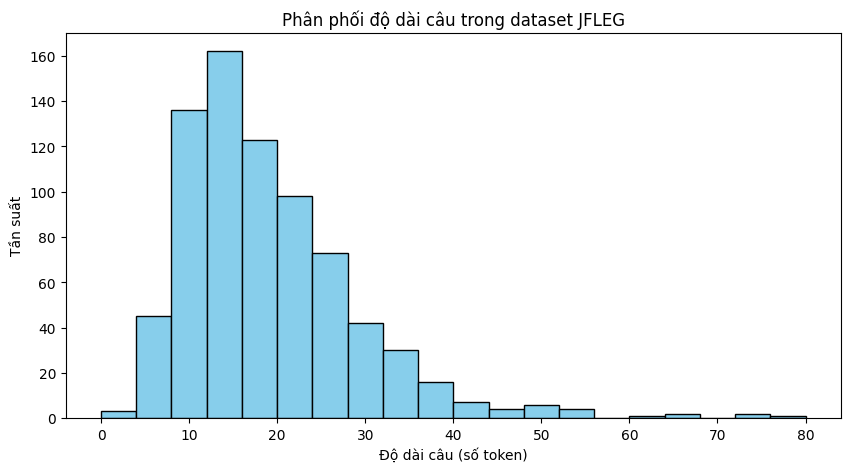

In [19]:
# 1. Histogram phân phối độ dài câu (số token)
sentence_lengths = []
for example in all_data:
    sentence = example['sentence']
    tokens = word_tokenize(sentence)
    sentence_lengths.append(len(tokens))

plt.figure(figsize=(10, 5))
plt.hist(sentence_lengths, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Độ dài câu (số token)')
plt.ylabel('Tần suất')
plt.title('Phân phối độ dài câu trong dataset JFLEG')
plt.show()

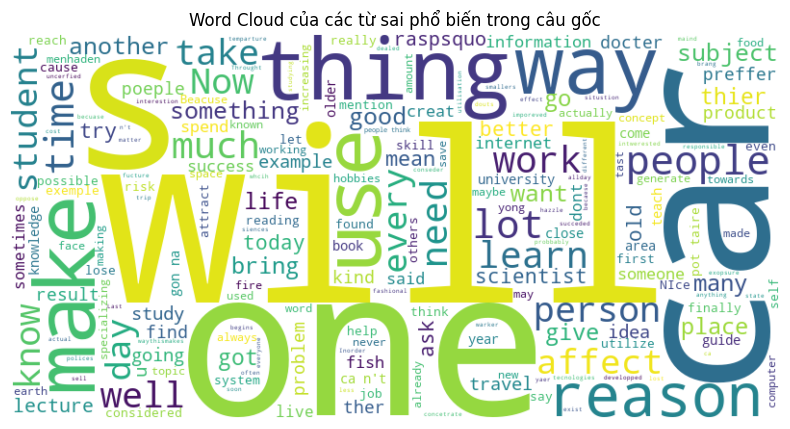

In [21]:
# 2. Word cloud cho các từ sai phổ biến trong tập source
erroneous_words = []
for example in all_data:
    sentence = example['sentence']
    source_tokens = word_tokenize(sentence)
    for correction in example['corrections']:
        correction_tokens = word_tokenize(correction)
        sm = difflib.SequenceMatcher(None, source_tokens, correction_tokens)
        for tag, i1, i2, j1, j2 in sm.get_opcodes():
            if tag == 'delete':
                erroneous_words.extend(source_tokens[i1:i2])
            elif tag == 'replace':
                erroneous_words.extend(source_tokens[i1:i2])

# Tạo và hiển thị word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(erroneous_words))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud của các từ sai phổ biến trong câu gốc')
plt.show()

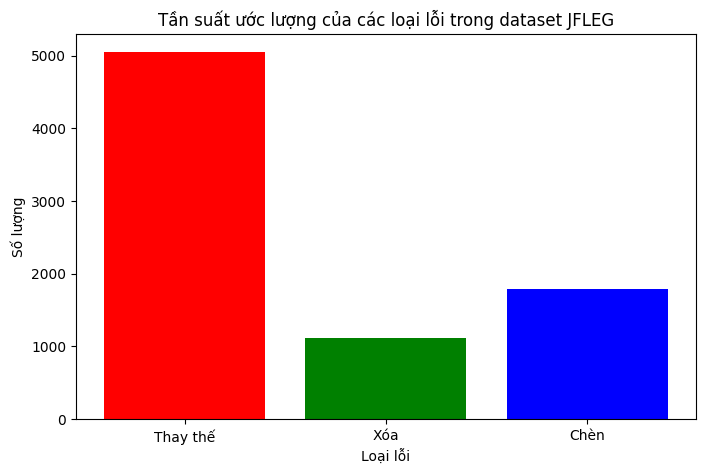

In [23]:
# 3. Biểu đồ bar ước lượng tỉ lệ các loại lỗi
error_counts = Counter()
for example in all_data:
    sentence = example['sentence']
    source_tokens = word_tokenize(sentence)
    for correction in example['corrections']:
        correction_tokens = word_tokenize(correction)
        sm = difflib.SequenceMatcher(None, source_tokens, correction_tokens)
        for tag, i1, i2, j1, j2 in sm.get_opcodes():
            if tag in ['delete', 'insert', 'replace']:
                error_counts[tag] += 1

error_types = {'delete': 'Xóa', 'insert': 'Chèn', 'replace': 'Thay thế'}
error_labels = [error_types[tag] for tag in error_counts.keys()]
counts = list(error_counts.values())

plt.figure(figsize=(8, 5))
plt.bar(error_labels, counts, color=['red', 'green', 'blue'])
plt.xlabel('Loại lỗi')
plt.ylabel('Số lượng')
plt.title('Tần suất ước lượng của các loại lỗi trong dataset JFLEG')
plt.show()